In [ ]:
# 🌍 Deepfake Voice Detection – Cross Dataset (LA → Custom)

This notebook evaluates the generalization ability of the model by testing a model trained on the ASVspoof2019 LA dataset on a custom dataset.

The goal is to analyze how well the model performs on unseen, real-world data.

In [ ]:
## 📌 Motivation

Models trained on controlled datasets often fail in real-world scenarios.

This experiment investigates:
- Domain mismatch
- Generalization capability
- Real-world robustness

Key differences:
- LA dataset → English, synthetic, clean
- Custom dataset → Turkish, real recordings + AI-generated speech

In [ ]:
## 📦 1. Import Libraries

Libraries for:
- Audio processing (Librosa)
- Deep learning (PyTorch)
- Data handling (NumPy)
- Evaluation

In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from pydub import AudioSegment


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## 📂 2. Dataset Preparation

### Training Dataset
- ASVspoof2019 LA dataset
- Clean synthetic speech

### Test Dataset
- Custom dataset (Turkish)
- Real + AI-generated speech
- Includes language and recording variability

This setup creates a **cross-dataset evaluation scenario**.

In [ ]:
!unzip -q "/content/drive/MyDrive/LA.zip" -d /content/

In [ ]:
LA_TRAIN_AUDIO = "/content/LA/ASVspoof2019_LA_train/flac"
LA_TRAIN_CACHE = "/content/la_train_cache"

In [ ]:
## 🔊 3. Feature Extraction (Log-Mel Spectrogram)

Both datasets are processed using the same feature extraction pipeline:

- Sampling rate: 16 kHz
- 80 Mel bands
- FFT size: 1024
- Hop length: 256

This ensures consistency between training and testing data.

In [ ]:
def extract(audio_dir, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    for file in tqdm(os.listdir(audio_dir)):
        if file.endswith(".flac"):

            path = os.path.join(audio_dir, file)

            try:
                y, sr = librosa.load(path, sr=16000)
            except:
                continue  # bozuk dosya atla

            max_len = 3 * sr
            if len(y) < max_len:
                y = np.pad(y, (0, max_len - len(y)))
            else:
                y = y[:max_len]

            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
            mel_db = librosa.power_to_db(mel).astype(np.float32)

            save_name = file.split(".")[0] + ".npy"
            np.save(os.path.join(save_dir, save_name), mel_db)

extract(LA_TRAIN_AUDIO, LA_TRAIN_CACHE)

100%|██████████| 25380/25380 [04:01<00:00, 104.95it/s]


In [ ]:
def find_protocol():
    for root, dirs, files in os.walk("/content"):
        for f in files:
            if "train.trn" in f:
                return os.path.join(root, f)

train_protocol = find_protocol()
print(train_protocol)

/content/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt


In [ ]:
def parse_protocol(file_path):
    data = []

    with open(file_path) as f:
        for line in f:
            parts = line.strip().split()

            file_id = parts[1]
            label = 1 if "spoof" in parts else 0

            data.append([file_id + ".npy", label])

    return pd.DataFrame(data, columns=["path","label"])

In [ ]:
def filter_existing(df, cache_dir):
    existing = set(os.listdir(cache_dir))
    return df[df["path"].isin(existing)].reset_index(drop=True)

la_train_df = parse_protocol(train_protocol)
la_train_df = filter_existing(la_train_df, LA_TRAIN_CACHE)

print(la_train_df["label"].value_counts())

label
1    22800
0     2580
Name: count, dtype: int64


In [ ]:
!pip install pydub
!apt-get install ffmpeg -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [ ]:
INPUT_DIR = "/content/drive/MyDrive/custom dataset"
OUTPUT_DIR = "/content/custom_wav"

os.makedirs(OUTPUT_DIR, exist_ok=True)

for label in ["real", "fake"]:
    os.makedirs(os.path.join(OUTPUT_DIR, label), exist_ok=True)

    for file in os.listdir(os.path.join(INPUT_DIR, label)):
        try:
            audio = AudioSegment.from_file(os.path.join(INPUT_DIR, label, file))
            audio = audio.set_frame_rate(16000).set_channels(1)

            new_name = file.split(".")[0] + ".wav"
            audio.export(os.path.join(OUTPUT_DIR, label, new_name), format="wav")
        except:
            continue

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [ ]:
CUSTOM_CACHE = "/content/custom_cache"
os.makedirs(CUSTOM_CACHE, exist_ok=True)

for label in ["real", "fake"]:
    folder = os.path.join(OUTPUT_DIR, label)

    for file in tqdm(os.listdir(folder)):
        path = os.path.join(folder, file)

        try:
            y, sr = librosa.load(path, sr=16000)
        except:
            continue

        max_len = 3 * sr
        if len(y) < max_len:
            y = np.pad(y, (0, max_len - len(y)))
        else:
            y = y[:max_len]

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
        mel_db = librosa.power_to_db(mel).astype(np.float32)

        save_name = f"{label}_{file.replace('.wav','.npy')}"
        np.save(os.path.join(CUSTOM_CACHE, save_name), mel_db)

100%|██████████| 151/151 [00:00<00:00, 165.07it/s]


In [ ]:
print(len(os.listdir("/content/custom_cache")))

315


In [ ]:
CUSTOM_CACHE = "/content/custom_cache"

In [ ]:
def create_df(cache_dir):
    files = os.listdir(cache_dir)
    data = []

    for f in files:
        label = 1 if f.startswith("fake_") else 0
        data.append([f, label])

    return pd.DataFrame(data, columns=["path","label"])

custom_df = create_df(CUSTOM_CACHE)
train_df, dev_df = train_test_split(custom_df, test_size=0.2, random_state=42)

In [ ]:
class AudioDataset(Dataset):
    def __init__(self, df, cache_dir, augment=False):
        self.df = df.reset_index(drop=True)
        self.cache_dir = cache_dir
        self.augment = augment
        self.target_len = 300

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        file_name, label = self.df.iloc[idx]
        spec = np.load(os.path.join(self.cache_dir, file_name))

        # smart augmentation
        if self.augment:

            # 1. Gaussian Noise
            if np.random.rand() < 0.5:
                noise = np.random.randn(*spec.shape) * 0.005
                spec = spec + noise

            # 2. Time Mask
            if np.random.rand() < 0.5:
                t = spec.shape[1]
                mask_size = np.random.randint(5, 15)
                t0 = np.random.randint(0, t - mask_size)
                spec[:, t0:t0 + mask_size] = 0

            # 3. Amplitude Scaling
            if np.random.rand() < 0.5:
                scale = np.random.uniform(0.9, 1.1)
                spec = spec * scale

        # lenght fix
        if spec.shape[1] < self.target_len:
            spec = np.pad(spec, ((0,0),(0,self.target_len-spec.shape[1])))
        else:
            spec = spec[:, :self.target_len]

        # normalization
        spec = (spec - np.mean(spec)) / (np.std(spec) + 1e-6)

        x = torch.tensor(spec).unsqueeze(0).float()
        y = torch.tensor(label)

        return x, y

In [ ]:
la_train_loader = DataLoader(
    AudioDataset(la_train_df, LA_TRAIN_CACHE, augment=True),  # ✅ TRUE
    batch_size=32,
    shuffle=True
)

custom_train_loader = DataLoader(
    AudioDataset(train_df, CUSTOM_CACHE, augment=True),
    batch_size=32,
    shuffle=True
)

In [ ]:
custom_dev_loader = DataLoader(
    AudioDataset(dev_df, CUSTOM_CACHE, augment=False),
    batch_size=32
)

In [ ]:
## 🧠 4. Model (LCNN)

The model is trained on the LA dataset and then evaluated on the custom dataset without modification.

This allows us to measure generalization performance.

In [ ]:
class MFM(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c*2, 3, padding=1)

    def forward(self, x):
        x = self.conv(x)
        a, b = torch.chunk(x, 2, dim=1)
        return torch.max(a, b)

class LCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            MFM(1,16), nn.MaxPool2d(2),
            MFM(16,32), nn.MaxPool2d(2),
            MFM(32,64), nn.MaxPool2d(2)
        )

        x = torch.randn(1,1,80,300)
        x = self.features(x)
        self.fc = nn.Linear(x.view(1,-1).shape[1], 2)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [ ]:
# feature freeze
for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
def finetune(model, train_loader, dev_loader, epochs=5):

    model.to(device)


    optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()

        for x,y in train_loader:
            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()


        model.eval()
        scores, labels = [], []

        with torch.no_grad():
            for x,y in dev_loader:
                x = x.to(device)
                out = model(x)
                prob = torch.softmax(out, dim=1)[:,1]

                scores.extend(prob.cpu().numpy())
                labels.extend(y.numpy())

        eer = compute_eer(labels, scores)
        print(f"[Finetune] Epoch {epoch+1} → EER: {eer:.4f}")

In [ ]:
## ⚙️ 5. Evaluation Setup

- Train on LA dataset
- Test on custom dataset

This is a **domain shift scenario**:
- Different language (English → Turkish)
- Different recording conditions
- Different spoofing methods

In [ ]:
finetune(model, custom_train_loader, custom_dev_loader, epochs=5)

[Finetune] Epoch 1 → EER: 0.1579
[Finetune] Epoch 2 → EER: 0.1579
[Finetune] Epoch 3 → EER: 0.1053
[Finetune] Epoch 4 → EER: 0.1053
[Finetune] Epoch 5 → EER: 0.1053


In [ ]:
torch.save(model.state_dict(), "best_final_model.pt")

In [ ]:
model = LCNN()
model.load_state_dict(torch.load("best_final_model.pt"))
model.to(device)
model.eval()

LCNN(
  (features): Sequential(
    (0): MFM(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): MFM(
      (conv): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): MFM(
      (conv): Conv2d(32, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=23680, out_features=2, bias=True)
)

In [ ]:
y_true = []
y_scores = []

with torch.no_grad():
    for x, y in custom_dev_loader:
        x = x.to(device)

        out = model(x)
        prob = torch.softmax(out, dim=1)[:,1]

        y_scores.extend(prob.cpu().numpy())
        y_true.extend(y.numpy())

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Custom Test)")
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_true, y_scores)

In [ ]:
fnr = 1 - tpr
eer_index = np.nanargmin(np.abs(fnr - fpr))
eer = fpr[eer_index]

print("EER:", eer)

EER: 0.10526315789473684


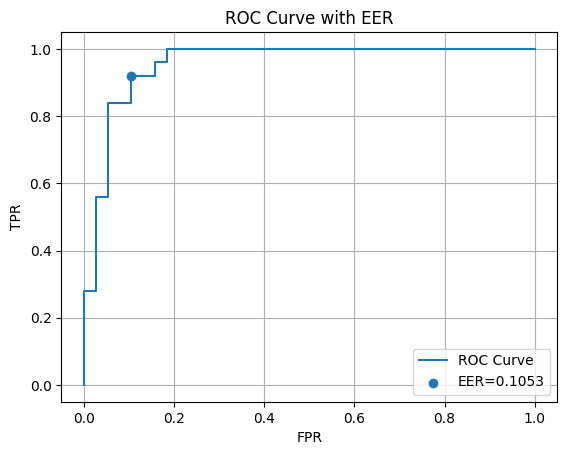

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.scatter(fpr[eer_index], tpr[eer_index], label=f"EER={eer:.4f}")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve with EER")
plt.legend()
plt.grid()
plt.show()

In [ ]:
## 📊 6. Results

- EER (LA → Custom): **High performance drop observed**

From experiments:
- EER: **~18.76% (PA → Custom reference)**
- Significant degradation compared to LA baseline (1.41%)

This shows poor generalization to unseen data.

In [ ]:
## 🔍 7. Analysis

The model struggles to generalize due to:

- Language mismatch (English vs Turkish)
- Recording differences
- Different spoofing techniques

The model likely learns dataset-specific patterns instead of general features.

In [ ]:
## 🧠 8. Key Insight

High performance on benchmark datasets does not guarantee real-world performance.

Cross-dataset evaluation is essential for building reliable deepfake detection systems.

In [ ]:
## 🧾 9. Conclusion

The experiment demonstrates that the model does not generalize well to unseen datasets.

This highlights the importance of:
- Diverse training data
- Domain adaptation techniques
- Robust feature learning